# Классификация

In [415]:
## !pip install imbalanced-learn

In [416]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

import seaborn as sns
import matplotlib.pyplot as plt

In [417]:
data = pd.read_csv('../data/processed_smoke_detector.csv')

### Проверим баланс классов

Соотношение классов(1/0): 0.7805901035226804


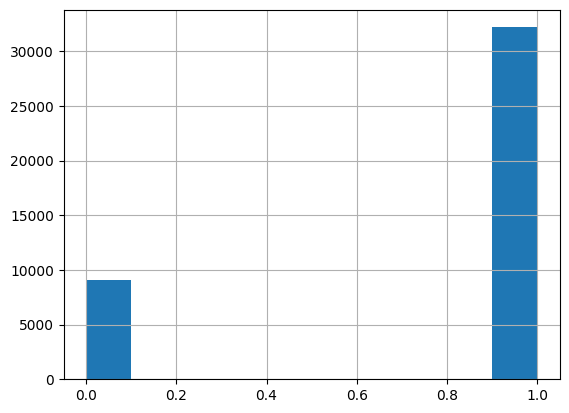

In [418]:
data['Fire Alarm'].hist()
print('Соотношение классов(1/0):', data['Fire Alarm'].sum()/data.shape[0])

Классы распределены неравномерно, воспользуемся библиотекой imbalance-learn

In [419]:
X = data.drop('Fire Alarm', axis=1)
y = data['Fire Alarm']
print(X.shape, y.shape)

(41247, 12) (41247,)


In [420]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [421]:
oversample = SMOTE(random_state=42)
X_train, y_train = oversample.fit_resample(X_train, y_train)
print(X_train.shape, y_train.shape)
print(y_train.value_counts())

(51514, 12) (51514,)
Fire Alarm
1    25757
0    25757
Name: count, dtype: int64


## Стандартизация данных

In [422]:
# scaler = StandardScaler()
# X_traind = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

Без стандартизации данных модели показывают лучшие результаты

## Logistic Regression

In [423]:
from sklearn.linear_model import LogisticRegression

In [424]:
lr = LogisticRegression(max_iter=10**6)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000000)

In [425]:
y_lr_pred = lr.predict(X_test)

In [426]:
print(accuracy_score(y_test, y_lr_pred))
print(confusion_matrix(y_test, y_lr_pred))
print(classification_report(y_test, y_lr_pred))

0.9995151515151515
[[1810    0]
 [   4 6436]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1810
           1       1.00      1.00      1.00      6440

    accuracy                           1.00      8250
   macro avg       1.00      1.00      1.00      8250
weighted avg       1.00      1.00      1.00      8250



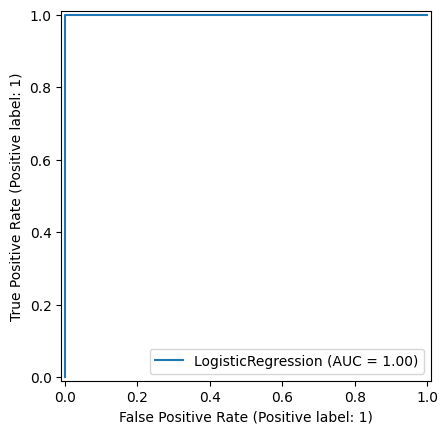

In [427]:
RocCurveDisplay.from_estimator(lr, X_test, y_test)

## kNN

In [428]:
oversample = SMOTE(random_state=42)
X_train, y_train = oversample.fit_resample(X_train, y_train)
print(X_train.shape, y_train.shape)
print(y_train.value_counts())

(51514, 12) (51514,)
Fire Alarm
1    25757
0    25757
Name: count, dtype: int64


In [429]:
from sklearn.neighbors import KNeighborsClassifier

Данная задача является задачей бинарной классификации, поэтому возьмем нечетное k

In [430]:

knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2) # p=2 для использования евклидового расстояния
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [431]:
y_bin_knn_pred = knn.predict(X_test)

In [432]:
accuracy_score(y_test, y_bin_knn_pred)

1.0

In [433]:
confusion_matrix(y_test, y_bin_knn_pred)

array([[1810,    0],
       [   0, 6440]])

In [434]:
print(classification_report(y_test, y_bin_knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1810
           1       1.00      1.00      1.00      6440

    accuracy                           1.00      8250
   macro avg       1.00      1.00      1.00      8250
weighted avg       1.00      1.00      1.00      8250



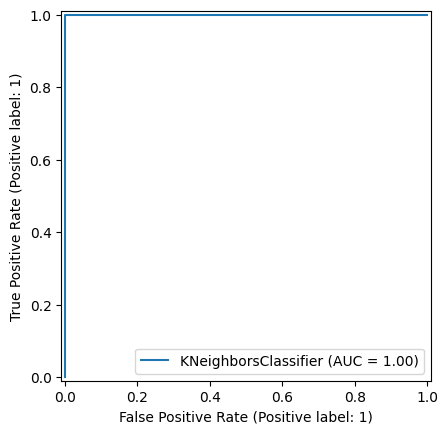

In [435]:
RocCurveDisplay.from_estimator(knn, X_test, y_test)

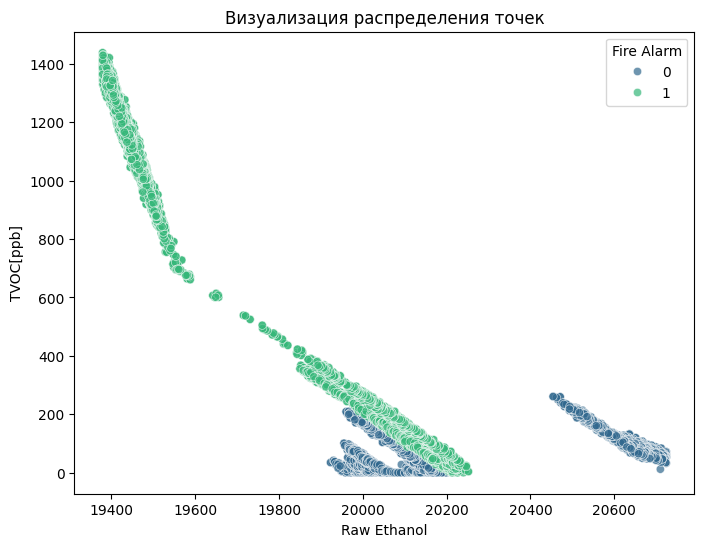

In [436]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Raw Ethanol', 
                y='TVOC[ppb]', 
                hue='Fire Alarm', 
                data=data, 
                palette='viridis', 
                alpha=0.7)
plt.title('Визуализация распределения точек')
plt.xlabel('Raw Ethanol')
plt.ylabel('TVOC[ppb]')
plt.show()

## Naive Bayes

In [437]:
from sklearn.naive_bayes import GaussianNB

In [438]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [439]:
y_gnb_pred = gnb.predict(X_test)

In [440]:
print(classification_report(y_test, y_gnb_pred))

              precision    recall  f1-score   support

           0       1.00      0.60      0.75      1810
           1       0.90      1.00      0.95      6440

    accuracy                           0.91      8250
   macro avg       0.95      0.80      0.85      8250
weighted avg       0.92      0.91      0.90      8250

